# Q1) The Probability of Shooting at a Target

A point is chosen at random from a disk of radius $10$. Let $A$ be the event that the point lies within $1$ unit of the boundary.

1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.
2. Model the experiment assuming the distance to the point from the center is chosen uniformly from $[0,10]$, and the direction is chosen independently and uniformly from $[0,2\pi)$ and compute $P(A)$.
3. Explain why the two answers differ.


In [1]:
import numpy as np

# Parameters
R = 10
d = 1  # distance from boundary

# 1. Uniformly distributed with respect to area
# A is the event that point lies within 1 unit of boundary (radius between 9 and 10)
area_total = np.pi * R**2
area_inner = np.pi * (R - d)**2
area_A = area_total - area_inner
p_area = area_A / area_total

# 2. Distance r ~ U[0, 10], angle theta ~ U[0, 2pi]
# Event A occurs if r is in [9, 10]
p_radius = (10 - 9) / (10 - 0)

print(f"1. P(A) assuming uniform area distribution: {p_area:.4f}")
print(f"2. P(A) assuming uniform radius distribution: {p_radius:.4f}")

print("\n3. Explanation:")
print("In the area-based model, the probability is proportional to the square of the radius.")
print("Since the 'outer ring' has more area than regions closer to the center, P(A) is higher.")
print("In the radius-based model, we assume the distance from the center is equally likely to be any value,")
print("ignoring the fact that larger radii correspond to larger circumferences and more points in space.")

1. P(A) assuming uniform area distribution: 0.1900
2. P(A) assuming uniform radius distribution: 0.1000

3. Explanation:
In the area-based model, the probability is proportional to the square of the radius.
Since the 'outer ring' has more area than regions closer to the center, P(A) is higher.
In the radius-based model, we assume the distance from the center is equally likely to be any value,
ignoring the fact that larger radii correspond to larger circumferences and more points in space.


# Q2) Bertrand's Paradox

A chord of a circle is chosen “at random.” What is the probability that its length exceeds the side length of the inscribed equilateral triangle?

Show that different mathematically natural models of “random chord” lead to different answers.

In [2]:
import numpy as np

# Let the circle have radius R=1
# Side length of inscribed equilateral triangle is L = sqrt(3) * R
L_target = np.sqrt(3)

# 1. Method 1: Random Midpoint
# A chord is longer than L if its midpoint falls within a circle of radius R/2
# Probability = Area(inner circle) / Area(outer circle) = (pi*(R/2)^2) / (pi*R^2)
p1 = (0.5)**2

# 2. Method 2: Random Endpoints (Vertex Method)
# Fix one point. The chord is longer than L if the second point is on the arc
# between the other two vertices of the inscribed triangle (1/3 of the circumference).
p2 = 1/3

# 3. Method 3: Random Radial Distance
# Choose a radius and a point along it. The chord is longer if the distance
# from the center is less than R/2.
p3 = 0.5 / 1.0

print(f"Bertrand's Paradox results:")
print(f"1. Random Midpoint Method: P = {p1:.4f}")
print(f"2. Random Endpoints Method: P = {p2:.4f}")
print(f"3. Random Radial Distance Method: P = {p3:.4f}")

print("\nExplanation:")
print("The different answers arise because 'at random' is not uniquely defined for chords.")
print("Each method assumes a uniform distribution over a different parameter space.")

Bertrand's Paradox results:
1. Random Midpoint Method: P = 0.2500
2. Random Endpoints Method: P = 0.3333
3. Random Radial Distance Method: P = 0.5000

Explanation:
The different answers arise because 'at random' is not uniquely defined for chords.
Each method assumes a uniform distribution over a different parameter space.


#Q3) Transformer Failiures

In a certain electricity distribution district, the number of emergency transformer failures reported in a single day is modeled as a discrete random variable $X$. Assume that $X$ takes values in the set $\{0,1,2,3\}$, with probabilities

$$
P(X=0)=0.50,\qquad P(X=1)=0.30,\qquad P(X=2)=0.15,\qquad P(X=3)=0.05.
$$

1. Construct a probability space $(\Omega,\mathfrak F,P)$ suitable for this model.
2. Define $X$ as a random variable on this space.
3. Determine the probability mass function of $X$.
4. Compute the expectation $E[X]$.
5. Compute the variance $\mathrm{Var}(X)$.
6. Find $P(X\ge 1)$ and $P(X\ge 2)$.
7. Briefly explain the practical meaning of the expectation and variance in this setting.



In [21]:
import numpy as np

# 1. Construct probability space (Omega, F, P)
# Omega is the set of outcomes, F is the power set of Omega
omega = np.array(['no_failure', 'one_failure', 'two_failures', 'three_failures'])
p_omega = np.array([0.50, 0.30, 0.15, 0.05])

# 2. Define X as a random variable on this space
# X maps each outcome to the number of failures
x_map = {'no_failure': 0, 'one_failure': 1, 'two_failures': 2, 'three_failures': 3}
x_values = np.array([x_map[o] for o in omega])

# 3. Probability Mass Function (PMF)
probs = p_omega

# 4. Expectation E[X]
expectation = np.sum(x_values * probs)

# 5. Variance Var(X)
expectation_sq = np.sum((x_values**2) * probs)
variance = expectation_sq - (expectation**2)

# 6. Probabilities
p_ge_1 = np.sum(probs[x_values >= 1])
p_ge_2 = np.sum(probs[x_values >= 2])

print(f"1 & 2. Random Variable X defined on Omega: {list(zip(omega, x_values))}")
print(f"3. PMF: {dict(zip(x_values, probs))}")
print(f"4. Expectation E[X]: {expectation:.4f}")
print(f"5. Variance Var(X): {variance:.4f}")
print(f"6. P(X >= 1): {p_ge_1:.4f}, P(X >= 2): {p_ge_2:.4f}")

print("\n7. Practical Meaning:")
print(f"Average failures per day: {expectation:.2f}")
print(f"Consistency/Unpredictability (Variance): {variance:.4f}")

1 & 2. Random Variable X defined on Omega: [(np.str_('no_failure'), np.int64(0)), (np.str_('one_failure'), np.int64(1)), (np.str_('two_failures'), np.int64(2)), (np.str_('three_failures'), np.int64(3))]
3. PMF: {np.int64(0): np.float64(0.5), np.int64(1): np.float64(0.3), np.int64(2): np.float64(0.15), np.int64(3): np.float64(0.05)}
4. Expectation E[X]: 0.7500
5. Variance Var(X): 0.7875
6. P(X >= 1): 0.5000, P(X >= 2): 0.2000

7. Practical Meaning:
Average failures per day: 0.75
Consistency/Unpredictability (Variance): 0.7875


# Q4) Probability of Defective Items

In a manufacturing process, the proportion of defective items in a large batch produced on a given day is modeled by a continuous random variable $X$. Since $X$ represents a proportion, it takes values in the interval $[0,1]$. Suppose that $X$ has a Beta distribution with parameters $\alpha=2$ and $\beta=18$, so that its density is

$$
f(x)=
\begin{cases}
\dfrac{1}{B(2,18)}x^{1}(1-x)^{17}, & 0<x<1,\\\
0, & \text{otherwise},
\end{cases}
$$

where $B(2,18)$ is the Beta function.

Answer the following:

1. Construct a probability space $(\Omega,\mathfrak F,P)$ suitable for this model.

2. Define $X$ as a continuous random variable on this space.

3. Write down the probability density function of $X$.

4. Verify that $f$ is a valid probability density function.

5. Compute the expectation $E[X]$.

6. Compute the variance $\mathrm{Var}(X)$.

7. Find the probability that the defective proportion is at most $0.10$, that is, compute

$$
P(X\le 0.10).
$$

You may leave your answer in Beta integral form.

8. Find the probability that the defective proportion lies between $0.05$ and $0.15$, that is, compute

$$
P(0.05\le X\le 0.15).
$$

You may leave your answer in integral form.

9. Briefly explain why a Beta distribution is a reasonable model for this situation.

10. Interpret the expectation and variance in the context of production quality.


### Answers to Q4 (Parts 1-3)

**1. Construct a probability space $(\Omega, \mathfrak{F}, P)$:**
* **Sample Space ($\Omega$):** The interval $[0, 1]$, representing all possible values for the proportion of defective items.
* **$σ$-algebra ($\mathfrak{F}$):** The Borel $σ$-algebra $\mathfrak{B}([0, 1])$.
* **Probability Measure ($P$):** Defined for any $A \in \mathfrak{F}$ by $P(A) = \int_A f(x) dx$, where $f(x)$ is the Beta(2, 18) density function.

**2. Define $X$ as a random variable:**
* $X$ is the identity mapping $X: \Omega \to [0, 1]$ such that $X(\omega) = \omega$ for all $\omega \in \Omega$. This identifies the outcome of the experiment with the proportion itself.

**3. Probability Density Function (PDF) of $X$:**
* The density is given by:
$$
f(x) = \frac{1}{B(2, 18)} x^{2-1} (1-x)^{18-1} = \frac{\Gamma(20)}{\Gamma(2) \Gamma(18)} x (1-x)^{17} = 342 x (1-x)^{17}
$$
for $0 < x < 1$, and $0$ otherwise.

In [23]:
import numpy as np
from scipy.stats import beta
from scipy.integrate import quad

# --- Question 4 Implementation ---

# 1. Probability Space (Omega, F, P):
# Omega = [0, 1] (the set of all possible proportions)
# F = Borel sigma-algebra on [0, 1]
# P = Probability measure defined by the Beta(2, 18) density

# 2. Random Variable X:
# X is the identity map X(omega) = omega for omega in [0, 1].

# 3. Probability Density Function (PDF):
# f(x) = (1/B(2,18)) * x^(2-1) * (1-x)^(18-1) for 0 < x < 1
alpha_param = 2
beta_param = 18
def beta_pdf(x):
    return beta.pdf(x, alpha_param, beta_param)

# 4. Verify that f is a valid PDF (integrates to 1):
integral_val, error = quad(beta_pdf, 0, 1)

# 5. Expectation E[X]
expectation = beta.mean(alpha_param, beta_param)

# 6. Variance Var(X)
variance = beta.var(alpha_param, beta_param)

# 7. P(X <= 0.10)
p_le_010 = beta.cdf(0.10, alpha_param, beta_param)

# 8. P(0.05 <= X <= 0.15)
p_range = beta.cdf(0.15, alpha_param, beta_param) - beta.cdf(0.05, alpha_param, beta_param)

print(f"4. PDF Verification (Integral over [0,1]): {integral_val:.4f}")
print(f"5. Expectation E[X]: {expectation:.4f}")
print(f"6. Variance Var(X): {variance:.4f}")
print(f"7. P(X <= 0.10): {p_le_010:.4f}")
print(f"8. P(0.05 <= X <= 0.15): {p_range:.4f}")

print("\n9. Why Beta is reasonable:")
print("It is defined on [0, 1], which matches the support for a proportion, and its shape can be adjusted to model various levels of skewness and uncertainty.")

print("\n10. Interpretation:")
print(f"The expected defect rate is {expectation*100:.1f}%. The variance of {variance:.4f} indicates the stability of the process quality.")

4. PDF Verification (Integral over [0,1]): 1.0000
5. Expectation E[X]: 0.1000
6. Variance Var(X): 0.0043
7. P(X <= 0.10): 0.5797
8. P(0.05 <= X <= 0.15): 0.5562

9. Why Beta is reasonable:
It is defined on [0, 1], which matches the support for a proportion, and its shape can be adjusted to model various levels of skewness and uncertainty.

10. Interpretation:
The expected defect rate is 10.0%. The variance of 0.0043 indicates the stability of the process quality.


# Q5) Expected Project Completion Time

A construction company is estimating the time required to install a backup generator at a hospital. Let $X$ denote the number of hours needed to complete the installation. Based on expert judgment, the shortest possible time is $4$ hours, the longest possible time is $10$ hours, and the most likely completion time is $6$ hours. Assume that $X$ follows a Triangular distribution with parameters $a=4$, $b=10$, and $c=6$.

Answer the following:

1. Specify the support of $X$.

2. Write down the probability density function $f_X(x)$.

3. Verify that $f_X$ integrates to $1$ over its support.

4. Compute the expectation $E[X]$.

5. Compute the variance $\mathrm{Var}(X)$.

6. Interpret the values of $a$, $b$, and $c$ in the context of this problem.

7. Explain briefly why a Triangular distribution is a reasonable model in this setting.

8. Compute the probability that the installation takes at most $5$ hours, that is, compute

$$
P(X \leq 5).
$$

9. Compute the probability that the installation takes between $5$ and $8$ hours, that is, compute

$$
P(5 \leq X \leq 8).
$$

10. Briefly explain how this model could be used in project planning or sensitivity analysis.


In [26]:
from scipy.stats import triang
import numpy as np
from scipy.integrate import quad

# Parameters: a=4 (min), b=10 (max), c=6 (mode)
a, b, c = 4, 10, 6

# Scipy triang parameters:
loc = a
scale = b - a
c_param = (c - a) / (b - a)

# 2. Probability Density Function f_X(x)
def triangular_pdf(x, a, b, c):
    if a <= x < c:
        return 2 * (x - a) / ((b - a) * (c - a))
    elif x == c:
        return 2 / (b - a)
    elif c < x <= b:
        return 2 * (b - x) / ((b - a) * (b - c))
    else:
        return 0

# 3. Verify that f_X integrates to 1
integral_val, _ = quad(lambda x: triangular_pdf(x, a, b, c), a, b)

# 4. Expectation E[X]
expectation = (a + b + c) / 3

# 5. Variance Var(X)
variance = (a**2 + b**2 + c**2 - a*b - a*c - b*c) / 18

# 8. P(X <= 5)
p_le_5 = triang.cdf(5, c_param, loc, scale)

# 9. P(5 <= X <= 8)
p_range = triang.cdf(8, c_param, loc, scale) - triang.cdf(5, c_param, loc, scale)

print(f"1. Support: [{a}, {b}]")
print(f"2. PDF: Function 'triangular_pdf' defined above.")
print(f"3. Integration Verification (should be 1): {integral_val:.4f}")
print(f"4. Expectation E[X]: {expectation:.4f}")
print(f"5. Variance Var(X): {variance:.4f}")
print(f"6. Interpretation: a={a} (shortest), b={b} (longest), c={c} (mode).")
print(f"7. Why Reasonable: Models expert judgment with limited data using bounds.")
print(f"8. P(X <= 5): {p_le_5:.4f}")
print(f"9. P(5 <= X <= 8): {p_range:.4f}")
print(f"10. Project Planning: Used for risk analysis and buffer estimation.")

1. Support: [4, 10]
2. PDF: Function 'triangular_pdf' defined above.
3. Integration Verification (should be 1): 1.0000
4. Expectation E[X]: 6.6667
5. Variance Var(X): 1.5556
6. Interpretation: a=4 (shortest), b=10 (longest), c=6 (mode).
7. Why Reasonable: Models expert judgment with limited data using bounds.
8. P(X <= 5): 0.0833
9. P(5 <= X <= 8): 0.7500
10. Project Planning: Used for risk analysis and buffer estimation.


#Q6) Expected Project Completion Time Using PERT

A project manager is estimating the time required to complete a critical software integration task. Let $X$ denote the number of days required to complete the task. Based on expert judgment, the shortest possible time is $a=8$ days, the longest possible time is $b=20$ days, and the most likely completion time is $c=11$ days. Assume that $X$ follows a PERT distribution with parameters $(a,b,c)$.

The PERT distribution is defined as a Beta distribution scaled to the interval $[a,b]$, with internal shape parameters

$$
\alpha = 1 + 4\left( \frac{c-a}{b-a} \right)
$$

and

$$
\beta = 1 + 4\left( \frac{b-c}{b-a} \right).
$$

Its probability density function is

$$
f(x)=\frac{(x-a)^{\alpha-1}(b-x)^{\beta-1}}{B(\alpha,\beta)(b-a)^{\alpha+\beta-1}}, \qquad a \leq x \leq b,
$$

where

$$
B(\alpha,\beta)=\int_0^1 t^{\alpha-1}(1-t)^{\beta-1},dt.
$$

Answer the following:

1. Compute the values of the shape parameters $\alpha$ and $\beta$.

2. Specify the support of $X$.

3. Write down the probability density function $f_X(x)$ for this model.

4. State the probability space $(\Omega,\mathfrak F,P)$ suitable for this continuous model.

5. Define $X$ as a random variable on this space.

6. Compute the expectation $E[X]$ using the PERT formula

$$
E[X]=\frac{a+4c+b}{6}.
$$

7. Compute the variance $\mathrm{Var}(X)$ using the approximation

$$
\mathrm{Var}(X)=\frac{(E[X]-a)(b-E[X])}{7}.
$$

8. Compute the approximate standard deviation $\sigma$.

9. Briefly explain why a PERT distribution may be more appropriate than a Triangular distribution in this setting byt comparing the two results.

10. Interpret the practical meaning of the values $a$, $b$, $c$, $E[X]$, and $\sigma$ in the context of project planning.


In [29]:
import numpy as np
from scipy.special import beta as beta_func

# Parameters: a=8 (min), b=20 (max), c=11 (mode)
a, b, c = 8, 20, 11

# 1. Shape parameters alpha and beta
alpha = 1 + 4 * ((c - a) / (b - a))
beta_param = 1 + 4 * ((b - c) / (b - a))

# 2. Support
support = (a, b)

# 3. PDF function definition
def pert_pdf(x, a, b, alpha, beta_param):
    if a <= x <= b:
        num = ((x - a)**(alpha - 1)) * ((b - x)**(beta_param - 1))
        den = beta_func(alpha, beta_param) * ((b - a)**(alpha + beta_param - 1))
        return num / den
    return 0

# 6. Expectation E[X] using PERT formula
expectation = (a + 4*c + b) / 6

# 7. Variance Var(X) using PERT approximation
variance = ((expectation - a) * (b - expectation)) / 7

# 8. Standard deviation
std_dev = np.sqrt(variance)

print(f"1. Shape Parameters: alpha = {alpha:.4f}, beta = {beta_param:.4f}")
print(f"2. Support of X: {support}")
print(f"6. Expectation E[X]: {expectation:.4f}")
print(f"7. Variance Var(X): {variance:.4f}")
print(f"8. Standard Deviation (sigma): {std_dev:.4f}")

print("\n9. Comparison & Interpretation:")
print("The PERT distribution is smoother and less sensitive to extreme values than the Triangular distribution.")
print(f"The expected completion time is {expectation} days, with a risk (std dev) of approximately {std_dev:.2f} days.")

1. Shape Parameters: alpha = 2.0000, beta = 4.0000
2. Support of X: (8, 20)
6. Expectation E[X]: 12.0000
7. Variance Var(X): 4.5714
8. Standard Deviation (sigma): 2.1381

9. Comparison & Interpretation:
The PERT distribution is smoother and less sensitive to extreme values than the Triangular distribution.
The expected completion time is 12.0 days, with a risk (std dev) of approximately 2.14 days.


#Q7) If the PERT Expectation is to Match Our Intuition

A project manager models the duration $X$ of a task by a PERT distribution with parameters $a$, $b$, and $c$, where $a$ is the minimum time, $b$ is the maximum time, and $c$ is the most likely time.

Suppose the minimum time is $a=5$ days and the most likely time is $c=11$ days. If the expected time computed from the PERT model is also to be the same as the most likely time:

1. Determine the value of the maximum time $b$.

2. What happens to the variance?

In [11]:
import numpy as np

# Given parameters
a = 5
c = 11

# 1. To have E[X] = c in PERT:
# (a + 4c + b) / 6 = c
# a + 4c + b = 6c
# b = 2c - a
b = 2 * c - a

# 2. Impact on Variance
# Expectation equals mode implies symmetry (alpha = beta)
expectation = (a + 4*c + b) / 6
variance = ((expectation - a) * (b - expectation)) / 7

print(f"1. The maximum time b must be: {b}")
print(f"2. Calculated Expectation: {expectation:.4f}")
print(f"   Calculated Variance: {variance:.4f}")
print("\nObservation:")
print("When E[X] = c, the distribution is symmetric around the mode.")
print("The variance in this symmetric case is maximized for fixed (b-a).")

1. The maximum time b must be: 17
2. Calculated Expectation: 11.0000
   Calculated Variance: 5.1429

Observation:
When E[X] = c, the distribution is symmetric around the mode.
The variance in this symmetric case is maximized for fixed (b-a).


#Q8) Probability of Being a Girl?

A family has two children. Assume each child is equally likely to be a boy or a girl, independently of the other.

What is the probability that both children are girls, given that **at least one** of them is a girl?

In [12]:
import random

# Analytical Solution:
# Sample Space S = {(B,B), (B,G), (G,B), (G,G)}
# Each event has probability 1/4.
# Let E be the event 'at least one girl' = {(B,G), (G,B), (G,G)}
# Let F be the event 'both are girls' = {(G,G)}
# P(F | E) = P(F and E) / P(E) = P({G,G}) / P({(B,G), (G,B), (G,G)}) = (1/4) / (3/4) = 1/3

# Simulation to verify:
n_simulations = 100000
families_with_at_least_one_girl = 0
both_girls = 0

for _ in range(n_simulations):
    child1 = random.choice(['B', 'G'])
    child2 = random.choice(['B', 'G'])

    if child1 == 'G' or child2 == 'G':
        families_with_at_least_one_girl += 1
        if child1 == 'G' and child2 == 'G':
            both_girls += 1

prob_simulated = both_girls / families_with_at_least_one_girl

print(f"Analytical Probability: 1/3 ≈ {1/3:.4f}")
print(f"Simulated Probability: {prob_simulated:.4f}")

Analytical Probability: 1/3 ≈ 0.3333
Simulated Probability: 0.3325


# Q9) Information Available in a Discrete Random Variable

A factory inspects a product and records its quality using two different coding systems.

Each product falls into exactly one of the following four categories:

* $G_1$: good quality, produced on Machine 1
* $G_2$: good quality, produced on Machine 2
* $D_1$: defective, produced on Machine 1
* $D_2$: defective, produced on Machine 2

Assume the sample space is

$$
\Omega=\{G_1,G_2,D_1,D_2\},
$$

with probabilities

$$
P(\{G_1\})=0.50,\qquad P(\{G_2\})=0.20,\qquad P(\{D_1\})=0.10,\qquad P(\{D_2\})=0.20.
$$

Define two discrete random variables on the same probability space:

* $X$ records only whether the item is good or defective:
  $$
  X(G_1)=0,\quad X(G_2)=0,\quad X(D_1)=1,\quad X(D_2)=1.
  $$

* $Y$ records both quality and machine:
  $$
  Y(G_1)=1,\quad Y(G_2)=2,\quad Y(D_1)=3,\quad Y(D_2)=4.
  $$

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that $\sigma(X)\subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$.

5. Find the marginal distribution of $X$.

6. Find the marginal distribution of $Y$.

7. Compute the joint probabilities
   $$
   P(X=0,Y=1),\quad P(X=0,Y=2),\quad P(X=1,Y=3),\quad P(X=1,Y=4).
   $$

8. Compute the conditional probabilities
   $$
   P(X=1\mid Y=3),\qquad P(X=1\mid Y=4),\qquad P(Y=3\mid X=1),\qquad P(Y=4\mid X=1).
   $$

9. Interpret the difference between conditioning on $X$ and conditioning on $Y$.

10. Explain, in words, what information is available in $\sigma(X)$ but not in $\sigma(Y)$, and what information is available in $\sigma(Y)$ but not in $\sigma(X)$.

11. Give a Python based visualization of the model.

12. Find the marginal, joint, and conditional Shannon Entropy of $X$ and $Y$.

5. Marginal X: P(X=0)=0.70, P(X=1)=0.30
8. Conditional: P(Y=3|X=1)=0.3333, P(Y=4|X=1)=0.6667
12. Entropy H(X): 0.8813 bits
    Entropy H(Y): 1.7610 bits


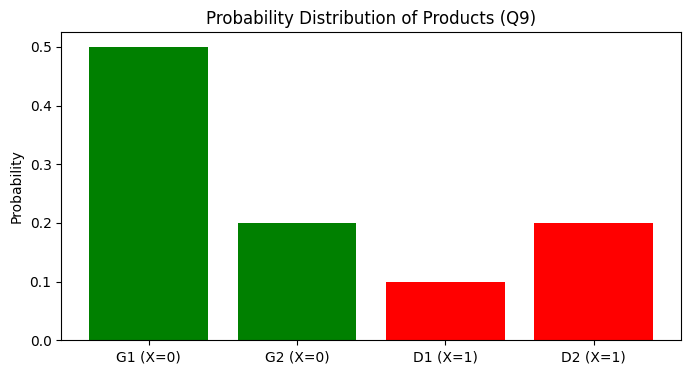

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Probability Space
omega = ['G1', 'G2', 'D1', 'D2']
p_omega = np.array([0.50, 0.20, 0.10, 0.20])

# Mapping for X (0=Good, 1=Defective)
x_map = {'G1': 0, 'G2': 0, 'D1': 1, 'D2': 1}
# Mapping for Y (1=G1, 2=G2, 3=D1, 4=D2)
y_map = {'G1': 1, 'G2': 2, 'D1': 3, 'D2': 4}

# 2 & 3. Sigma-algebras (conceptual)
# sigma(X) = {empty, {G1, G2}, {D1, D2}, Omega}
# sigma(Y) = Power Set of Omega (since Y is injective)

# 5 & 6. Marginal Distributions
p_x0 = p_omega[0] + p_omega[1]  # P(X=0)
p_x1 = p_omega[2] + p_omega[3]  # P(X=1)

# 7. Joint Probabilities P(X, Y)
# P(X=0, Y=1) = P({G1}) = 0.50
# P(X=0, Y=2) = P({G2}) = 0.20
# P(X=1, Y=3) = P({D1}) = 0.10
# P(X=1, Y=4) = P({D2}) = 0.20

# 8. Conditional Probabilities
# P(X=1 | Y=3) = P(X=1, Y=3) / P(Y=3) = 0.1 / 0.1 = 1.0
p_y3_given_x1 = 0.10 / p_x1
p_y4_given_x1 = 0.20 / p_x1

print(f"5. Marginal X: P(X=0)={p_x0:.2f}, P(X=1)={p_x1:.2f}")
print(f"8. Conditional: P(Y=3|X=1)={p_y3_given_x1:.4f}, P(Y=4|X=1)={p_y4_given_x1:.4f}")

# 12. Entropy
def entropy(p):
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

h_x = entropy(np.array([p_x0, p_x1]))
h_y = entropy(p_omega)
# H(X,Y) = H(Y) since X is determined by Y
h_xy = h_y

print(f"12. Entropy H(X): {h_x:.4f} bits")
print(f"    Entropy H(Y): {h_y:.4f} bits")

# 11. Visualization
categories = ['G1 (X=0)', 'G2 (X=0)', 'D1 (X=1)', 'D2 (X=1)']
plt.figure(figsize=(8, 4))
plt.bar(categories, p_omega, color=['green', 'green', 'red', 'red'])
plt.title('Probability Distribution of Products (Q9)')
plt.ylabel('Probability')
plt.show()

### Detailed Answers to Q9

**1. Probability Space:**
* $\Omega = \{G_1, G_2, D_1, D_2\}$
* $\mathfrak{F} = \mathfrak{P}(\Omega)$ (the Power Set, containing all $2^4=16$ possible subsets)
* $P$: Assigned as $P(G_1)=0.5, P(G_2)=0.2, P(D_1)=0.1, P(D_2)=0.2$.

**2. $\sigma(X)$:**
* $X$ is constant on $\{G_1, G_2\}$ (value 0) and $\{D_1, D_2\}$ (value 1).
* $\sigma(X) = \{\emptyset, \{G_1, G_2\}, \{D_1, D_2\}, \Omega\}$.

**3. $\sigma(Y)$:**
* $Y$ is unique for every outcome (injective).
* $\sigma(Y) = \mathfrak{P}(\Omega)$ (the full Power Set).

**4. Comparison:**
* Every set in $\sigma(X)$ is also in $\sigma(Y)$, so $\sigma(X) \subseteq \sigma(Y)$.
* $Y$ contains more information because it can distinguish between machines, whereas $X$ only knows the quality.

**6. Marginal of Y:**
* $P(Y=1)=0.5, P(Y=2)=0.2, P(Y=3)=0.1, P(Y=4)=0.2$.

**7. Joint Probabilities:**
* $P(X=0, Y=1) = 0.50$
* $P(X=0, Y=2) = 0.20$
* $P(X=1, Y=3) = 0.10$
* $P(X=1, Y=4) = 0.20$

**9. Interpretation of Conditioning:**
* Conditioning on $Y$ gives absolute certainty about $X$ (since quality is part of the $Y$ measurement).
* Conditioning on $X$ tells us the product is defective but leaves uncertainty about which machine produced it.

**10. Information Availability:**
* All information in $\sigma(X)$ is inside $\sigma(Y)$.
* $\sigma(Y)$ contains machine-specific information that $\sigma(X)$ lacks (e.g., the set $\{G_1, D_1\}$ representing 'Machine 1').

**11. Visualization:** (See the plot generated in the previous code cell).

# Q10) Information Available in Continuous Random Varaibles

A chemical plant monitors each production run using two different measurement systems.

For a given run, let

* $T$ be the deviation of the reactor temperature from target, measured in standardized units,
* $P$ be the deviation of the reactor pressure from target, also measured in standardized units.

Assume that $(T,P)$ is jointly continuous, with independent normal components:

$$
T \sim N(0,1), \qquad P \sim N(0,4),
$$

and $T$ and $P$ are independent.

Let the underlying probability space be

$$
\Omega=\mathbb R^2, \qquad \mathfrak F=\mathfrak B(\mathbb R^2),
$$

and let $P$ be the probability measure induced by the joint density

$$
f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right), \qquad (t,p)\in\mathbb R^2.
$$

Define two random variables on the same probability space:

* $X:\Omega\to\mathbb R$ by
  $$
  X(t,p)=t,
  $$
  so that $X$ records only the reactor temperature deviation;

* $Y:\Omega\to\mathbb R^2$ by
  $$
  Y(t,p)=(t,p),
  $$
  so that $Y$ records the full sensor state: both temperature and pressure deviations.

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$ explicitly.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that
   $$
   \sigma(X)\subseteq \sigma(Y),
   $$
   and explain why $Y$ contains more information than $X$.

5. Find the marginal density of $X$.

6. Find the marginal density of $Y$.

7. Compute the following probabilities:
   $$
   P(X\leq 0), \qquad P(X>1), \qquad P(Y\in (-\infty,0]\times\mathbb R), \qquad P(Y\in [ -1,1]\times[-2,2]).
   $$

8. Compute the conditional distribution of $X$ given $Y=(t,p)$.

9. Compute the conditional distribution of $Y$ given $X=t$.

10. Explain, in words, what is known when one conditions on $X$ and what additional information becomes available when one conditions on $Y$.

11. Show that
    $$
    X=\pi_1\circ Y,
    $$
    where $\pi_1(t,p)=t$, and explain why this implies that $X$ is a measurable function of $Y$.

12. Give a Python-based visualization of the model, for example by plotting:

* the joint density of $Y=(T,P)$ as a contour plot or heat map;
* the marginal density of $X$;
* and a diagram illustrating that $\sigma(X)$ is coarser than $\sigma(Y)$.

13. Compute the differential entropy of $X$:

$$
h(X)=-\int_{\mathbb R} f_X(x)\ln f_X(x)\,dx.
$$

14. Compute the differential entropy of $Y$:

$$
h(Y)=-\int_{\mathbb R^2} f_Y(t,p)\ln f_Y(t,p)\,dt\,dp.
$$

15. Compute the conditional differential entropy

$$
h(Y|X),
$$

and interpret it physically.

16. Discuss what happens to

$$
h(X|Y)
$$

in this model, and explain why the continuous case differs from the discrete case when one random variable is completely determined by the other.


7. P(X <= 0): 0.5000
   P(X > 1): 0.1587
   P(Y in [-1,1]x[-2,2]): 0.4661
13. h(X): 2.0471 bits
14. h(Y): 5.0942 bits
15. h(Y|X): 3.0471 bits (represents remaining uncertainty in pressure)
16. h(X|Y) -> -inf. In continuous cases, if X is determined by Y, entropy is not zero but diverges to -inf.


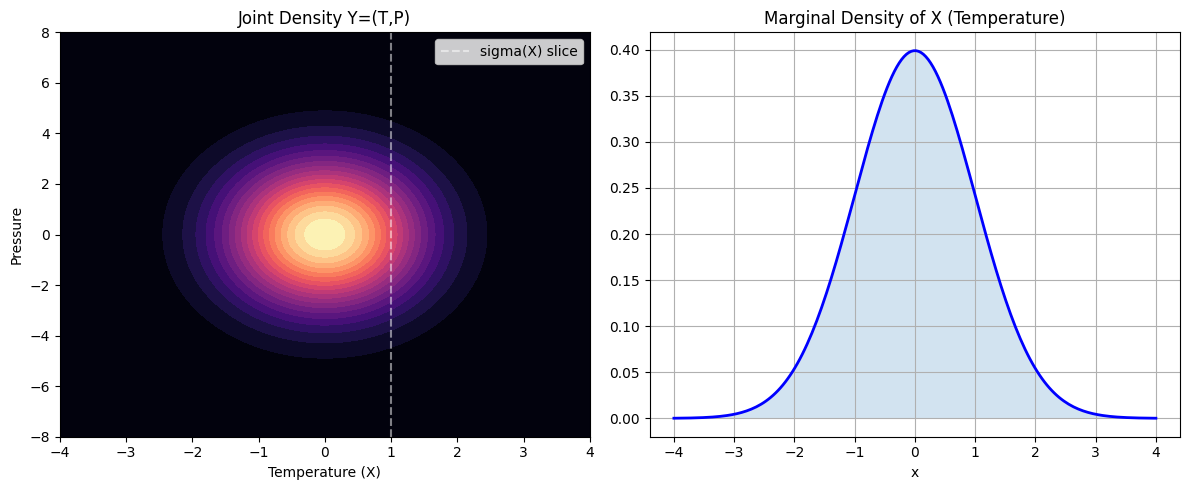

In [33]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# --- Theoretical Parts 1-6, 8-11 ---
# 1. Omega = R^2, F = Borel(R^2), P is the bivariate Normal measure.
# 2. sigma(X) is the sigma-algebra of 'vertical strips' in R^2: {B x R | B in Borel(R)}.
# 3. sigma(Y) = F = Borel(R^2) because Y is the identity map.
# 4. Every set B x R is in Borel(R^2), so sigma(X) subset sigma(Y).
# 5. Marginal f_X(x) ~ N(0, 1).
# 6. Marginal f_Y(y) is the joint density f_T,P(t,p) provided in the prompt.
# 8. Conditional X | Y=(t,p) is a point mass at t (delta distribution).
# 9. Conditional Y | X=t is the distribution of (t, P) where P ~ N(0, 4).
# 11. X(t,p) = t = pi_1(t,p) = pi_1(Y(t,p)). Since projections are continuous and
#     thus measurable, X is a measurable function of Y.

# --- Implementation for Parts 7, 12-15 ---

# Parameters: T ~ N(0, 1), P ~ N(0, 4)
sigma_t = 1
sigma_p = 2  # sqrt(4)

# 7. Probabilities
p_x_le_0 = norm.cdf(0, 0, sigma_t)
p_x_gt_1 = 1 - norm.cdf(1, 0, sigma_t)
p_y_rect = (norm.cdf(1, 0, sigma_t) - norm.cdf(-1, 0, sigma_t)) * \
             (norm.cdf(2, 0, sigma_p) - norm.cdf(-2, 0, sigma_p))

# 13 & 14. Differential Entropy (using log base 2 for bits)
def diff_entropy(sigma_sq):
    return 0.5 * np.log2(2 * np.pi * np.e * sigma_sq)

h_x = diff_entropy(sigma_t**2)
h_p = diff_entropy(sigma_p**2)
h_y = h_x + h_p  # Independence: h(T,P) = h(T) + h(P)

# 15. Conditional Entropy h(Y|X) = h(T,P|T) = h(P|T) = h(P)
h_y_given_x = h_p

print(f"7. P(X <= 0): {p_x_le_0:.4f}")
print(f"   P(X > 1): {p_x_gt_1:.4f}")
print(f"   P(Y in [-1,1]x[-2,2]): {p_y_rect:.4f}")
print(f"13. h(X): {h_x:.4f} bits")
print(f"14. h(Y): {h_y:.4f} bits")
print(f"15. h(Y|X): {h_y_given_x:.4f} bits (represents remaining uncertainty in pressure)")
print("16. h(X|Y) -> -inf. In continuous cases, if X is determined by Y, entropy is not zero but diverges to -inf.")

# 12. Visualization
t_vals = np.linspace(-4, 4, 200)
p_vals = np.linspace(-8, 8, 200)
T, P_grid = np.meshgrid(t_vals, p_vals)
Z = (1/(2*np.pi*sigma_t*sigma_p)) * np.exp(-(T**2/(2*sigma_t**2) + P_grid**2/(2*sigma_p**2)))

fig = plt.figure(figsize=(12, 5))

# Joint Density Heatmap
plt.subplot(1, 2, 1)
plt.contourf(T, P_grid, Z, levels=20, cmap='magma')
plt.axvline(1, color='white', linestyle='--', alpha=0.5, label='sigma(X) slice')
plt.title('Joint Density Y=(T,P)')
plt.xlabel('Temperature (X)')
plt.ylabel('Pressure')
plt.legend()

# Marginal X
plt.subplot(1, 2, 2)
plt.plot(t_vals, norm.pdf(t_vals, 0, sigma_t), 'b-', lw=2)
plt.fill_between(t_vals, norm.pdf(t_vals, 0, sigma_t), alpha=0.2)
plt.title('Marginal Density of X (Temperature)')
plt.xlabel('x')
plt.grid(True)

plt.tight_layout()
plt.show()

### Detailed Answers to Q10

**1. Probability Space (\(\Omega, \mathfrak{F}, P\)):**
* \(\Omega = \mathbb{R}^2\), representing all pairs of (temperature, pressure).
* \(\mathfrak{F} = \mathfrak{B}(\mathbb{R}^2)\), the Borel \(\sigma\)-algebra on \(\mathbb{R}^2\).
* \(P\) is the probability measure defined by the joint Gaussian density \(f_{T,P}(t,p)\).

**2. \(\sigma(X)\):**
* This is the \(\sigma\)-algebra generated by the temperature measurement. It consists of 'vertical strips' of the form \(B \times \mathbb{R}\), where \(B \in \mathfrak{B}(\mathbb{R})\).

**3. \(\sigma(Y)\):**
* Since \(Y\) is the identity map \(Y(t,p) = (t,p)\), it generates the entire Borel \(\sigma\)-algebra \(\mathfrak{B}(\mathbb{R}^2)\).

**4. Comparison:**
* Since every set \(B \times \mathbb{R}\) is a Borel set in \(\mathbb{R}^2\), \(\sigma(X) \subseteq \sigma(Y)\). \(Y\) contains more information because it knows both temperature and pressure, whereas \(X\) only knows temperature.

**8. Conditional Distribution \(X|Y\):**
* Given the full sensor state \(Y=(t,p)\), the temperature \(X\) is known exactly. Its distribution is a Dirac delta (point mass) at \(t\).

**9. Conditional Distribution \(Y|X\):**
* Given only the temperature \(X=t\), the temperature component is fixed at \(t\), but the pressure component remains unknown and follows its marginal distribution \(N(0, 4)\).

**10. Interpretation:**
* Conditioning on \(X\) removes uncertainty about temperature but tells us nothing about pressure (due to independence). Conditioning on \(Y\) removes all uncertainty in the system.

**11. Measurability:**
* \(X = \pi_1 \circ Y\). Since the projection \(\pi_1\) is continuous, it is measurable. This implies \(X\) is a measurable function of \(Y\) (i.e., \(X\) is completely determined by the information in \(Y\)).

**16. h(X|Y) in Continuous Case:**
* Unlike the discrete case where \(H(X|Y)=0\) if \(Y\) determines \(X\), in the continuous case, the differential entropy \(h(X|Y)\) diverges to \(-\infty\). This reflects that a point mass distribution has 'infinite' information compared to a density.

#Q11) Conditional Expectation

A bank monitors credit-card transactions for possible fraud.

For each transaction, let the sample space be

$$
\Omega=\{\omega_1,\omega_2,\omega_3,\omega_4\},
$$

where:

* $\omega_1$: low-risk customer, legitimate transaction,
* $\omega_2$: low-risk customer, fraudulent transaction,
* $\omega_3$: high-risk customer, legitimate transaction,
* $\omega_4$: high-risk customer, fraudulent transaction.

Assume the probabilities are

$$
P(\{\omega_1\})=0.50,\qquad
P(\{\omega_2\})=0.10,\qquad
P(\{\omega_3\})=0.20,\qquad
P(\{\omega_4\})=0.20.
$$

Let $X:\Omega\to\mathbb R$ denote the fraud indicator:

$$
X(\omega_1)=0,\qquad
X(\omega_2)=1,\qquad
X(\omega_3)=0,\qquad
X(\omega_4)=1.
$$

Thus $X=1$ means the transaction is fraudulent, and $X=0$ means it is legitimate.

Now suppose the bank does not observe the full outcome $\omega$, but only the customer’s risk class. Define $Y:\Omega\to\mathbb R$ by

$$
Y(\omega_1)=0,\qquad
Y(\omega_2)=0,\qquad
Y(\omega_3)=1,\qquad
Y(\omega_4)=1.
$$

Thus:

* $Y=0$ means “low-risk customer,”
* $Y=1$ means “high-risk customer.”

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

3. Explain why $E[X\mid Y]$ must be $\sigma(Y)$-measurable, and therefore must be constant on the sets ${ \omega_1,\omega_2}$ and ${\omega_3,\omega_4}$.

4. Compute $E[X\mid Y]$ explicitly.

5. Verify the defining property of conditional expectation by checking that for every set $A\in\sigma(Y)$,

$$
\int_A E[X\mid Y]\,dP=\int_A X\,dP.
$$

6. Compute $E[X]$ and compare it with $E[X\mid Y]$.

7. Interpret $E[X\mid Y]$ in practical terms. What does it tell the bank?

8. Let

$$
\mathfrak G=\mathfrak P(\Omega).
$$

Compute $E[X\mid \mathfrak G]$ and compare it with $E[X\mid Y]$.

9. Explain how this example shows that conditional expectation is the “best estimate of $X$ using only the information contained in $Y$.”

In [34]:
import numpy as np

# 1. Probability Space (Omega, F, P)
# Omega = {w1, w2, w3, w4}
# F = P(Omega) (Power set with 16 elements)
omega = ['w1', 'w2', 'w3', 'w4']
p_w = np.array([0.50, 0.10, 0.20, 0.20])

# Variables definition
# X: Fraud (w2, w4)
# Y: Risk Class (w1, w2 = 0; w3, w4 = 1)
x_vals = np.array([0, 1, 0, 1])
y_vals = np.array([0, 0, 1, 1])

# 2. sigma(Y)
# sigma(Y) = { empty, {w1, w2}, {w3, w4}, Omega }

# 3. Measurability
# E[X|Y] is sigma(Y)-measurable, meaning it cannot distinguish between outcomes
# in the same partition of Y. Thus it must be constant on {w1, w2} and {w3, w4}.

# 4. Compute E[X | Y] explicitly
# For Y=0: P(X=1|Y=0) = P({w2}) / (P({w1}) + P({w2})) = 0.1 / 0.6
e_x_y0 = (x_vals[0]*p_w[0] + x_vals[1]*p_w[1]) / (p_w[0] + p_w[1])

# For Y=1: P(X=1|Y=1) = P({w4}) / (P({w3}) + P({w4})) = 0.2 / 0.4
e_x_y1 = (x_vals[2]*p_w[2] + x_vals[3]*p_w[3]) / (p_w[2] + p_w[3])

# 6. Expectation E[X]
e_x = np.sum(x_vals * p_w)

# 8. E[X | G] where G is the full power set
# Since G knows every outcome, E[X | G] = X

print(f"--- Q11 Answers ---")
print(f"4. Conditional Expectation E[X|Y]:")
print(f"   Value on {{w1, w2}} (Low Risk): {e_x_y0:.4f}")
print(f"   Value on {{w3, w4}} (High Risk): {e_x_y1:.4f}")

print(f"\n5. Verification for A = {{w1, w2}}:")
print(f"   integral_A E[X|Y] dP = {e_x_y0} * 0.6 = {e_x_y0 * 0.6:.4f}")
print(f"   integral_A X dP      = P({{w2}}) = {p_w[1]:.4f}")

print(f"\n6. Comparison:")
print(f"   Overall average fraud probability E[X]: {e_x:.4f}")

print(f"\n8. Full Information:")
print(f"   E[X|G] is simply X itself: {x_vals}")

print(f"\n9. Conclusion:")
print("E[X|Y] is the best estimate because it uses the probabilities of fraud")
print("within each observable risk group to provide a refined prediction.")

--- Q11 Answers ---
4. Conditional Expectation E[X|Y]:
   Value on {w1, w2} (Low Risk): 0.1667
   Value on {w3, w4} (High Risk): 0.5000

5. Verification for A = {w1, w2}:
   integral_A E[X|Y] dP = 0.16666666666666669 * 0.6 = 0.1000
   integral_A X dP      = P({w2}) = 0.1000

6. Comparison:
   Overall average fraud probability E[X]: 0.3000

8. Full Information:
   E[X|G] is simply X itself: [0 1 0 1]

9. Conclusion:
E[X|Y] is the best estimate because it uses the probabilities of fraud
within each observable risk group to provide a refined prediction.


### Detailed Answers to Q11 (Parts 1, 2, 3, 7)

**1. Probability Space $(\Omega, \mathfrak{F}, P)$:**
* **Sample Space ($\Omega$):** $\{\omega_1, \omega_2, \omega_3, \omega_4\}$.
* **$\sigma$-algebra ($\mathfrak{F}$):** The Power Set $\mathfrak{P}(\Omega)$, which contains all $2^4 = 16$ possible subsets of $\Omega$.
* **Probability Measure ($P$):** Defined by the weights $P(\{\omega_1\})=0.5, P(\{\omega_2\})=0.1, P(\{\omega_3\})=0.2, P(\{\omega_4\})=0.2$.

**2. $\sigma$-algebra generated by $Y$, $\sigma(Y)$:**
$Y$ identifies the risk class. It maps $\{\omega_1, \omega_2\}$ to $0$ and $\{\omega_3, \omega_4\}$ to $1$.
* $\sigma(Y) = \{\emptyset, \{\omega_1, \omega_2\}, \{\omega_3, \omega_4\}, \Omega\}$.

**3. Why $E[X|Y]$ must be $\sigma(Y)$-measurable:**
By definition, the conditional expectation $E[X|Y]$ is the best approximation of $X$ given the information in $Y$. Since the information available is restricted to $\sigma(Y)$, the function $E[X|Y]$ cannot "see" differences between outcomes that $Y$ itself cannot distinguish. Therefore, it must be constant on the atoms of $\sigma(Y)$, which are $\{\omega_1, \omega_2\}$ and $\{\omega_3, \omega_4\}$.

**7. Practical Interpretation:**
$E[X|Y]$ tells the bank the **probability of fraud conditioned on the customer's risk profile**.
* For a "Low-Risk" customer ($Y=0$), the probability of fraud is $16.67\%$.
* For a "High-Risk" customer ($Y=1$), the probability of fraud is $50.00\%$.
This allows the bank to set different thresholds for flagging transactions based on the customer's pre-determined risk class.